# To-dos


- Check applicant quality
    - We might not find a direct effect of deal quality on the number of applications, but it might drive the number of high quality applications
- The effect of quality might not be significant when the deal is 'good enough', but it might be significant when the deal is 'bad'
    - Split the ratings into categories, and try to predict 'bad' vs. 'good enough' deals

----------

In [1]:
from src.analysis.regression_models import create_regression_runner
from src.analysis.engine import AnalysisEnvironment
from src.utils import interactive_regression_results_selector, simple_dashboard
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize

In [2]:
# Setup
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data(raw_filename='BARTER_DEALS_CLEAN.parquet')
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Finished loading experiment data
Found 0 experimental trials contaminated by garbage output.
Found 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 1000 rows with scale_size=5
  Processed 18578 rows with scale_size=4
Computing entropy for 2 different scale sizes: [np.int64(4), np.int64(5)]
  Processed 1000 rows with scale_size=5
  Processed 18578 rows with scale_size=4
PromptManager initialized with folder: ../prompts/PromptSuites/sandbox/BARTER_DEALS
Scanning 3 suites from ../prompts/PromptSuites/sandbox/BARTER_DEALS...
Loaded 3 PromptSuites


# Data cleaning

We consider a number of filtering approaches. Content type is a strong predictor, but some have too few observations to obtain a stable parameter estimate. E.g., Finance and Photography have only 15 and 5 observations respectively, and with a coefficient of $\approx -23$, in a log model their coefficient is effectively zero. Since they have near-zero applications in the entire dataset, we waste degrees of freedom trying to fit tiny noisy groups. We suggest a to filter category size to only include ones that have "signal" in their observations. 


- Remove obs with 0 applications

There are 'dead deals', where they have zero applications but are well-written. They have never been online at all, artificially inflating the zero-category with structural error (good deals that have no applications, while we know that good deals will get more applications). We remove the deals with 0 applications $n=865$, while retaining sufficient number of deals with 0 applications after 7 days $n=1650$


- Deals with a significant number of applications but no applications after 7 days

Some deals have no applications after 7 days, but a high total applications count. I observed that often these are good deals, but have no applications after 7 days for different reasons. The apps after 7 days variable is created using a specific starting date within in the database, but there is no 'clean' variable that measures when it actually went live. It could have been put live weeks after being created, so it garnered applications later than the initial seven-day period. Therefore, we remove observations where this difference is too big, indicating that the applications after 7 days is not representative of its actual performance. 


- Remove archived deals

We remove archived deals because they likely have never been put live 

- Average duplicate deal texts

We have deals that are identical, but with different numbers of applications. We take the average to remove some of the noise. 

- Partner filters

We remove $partner\_id=85$ because they are deals posted by Barter, they are part of Barter campaigns not the regular partner deals. 

- winsorizing (cap the variable at the 9xth percentile)

In count data (especially social media or job posts), "viral" outliers can distort the mean and variance. A single post with 1,000 applications (due to luck) adds massive noise.


In [ ]:
# 1. Define a minimum threshold (e.g., 50 observations)
def filter_low_n_categories(df, MIN_OBSERVATIONS=50):

    # 2. Count observations per category
    counts = df['first_content_type'].value_counts()

    # 3. Identify valid categories
    valid_categories = counts[counts >= MIN_OBSERVATIONS].index.tolist()

    print(f"Keeping {len(valid_categories)} categories: {valid_categories}")
    print(f"Dropping: {counts[counts < MIN_OBSERVATIONS].index.tolist()}")

    # 4. Filter the dataframe
    # Only keep rows where the content type is in our valid list
    return df[df['first_content_type'].isin(valid_categories)].copy()


def data_cleaning(ratings_df, MIN_CATEGORY_OBSERVATIONS: int = 50, PARTNER_IDS_TO_REMOVE: list = [85, 4],  diff_total_apps_7_days_floor=30):
    df = ratings_df.copy()

    # Remove categories with low number of observations (important if it is added as predictor)
    df = filter_low_n_categories(df, MIN_CATEGORY_OBSERVATIONS)

    # Remove obs with 0 applications
    df = df[df['applicants_applications_count'] > 0]

    # Deals with a significant number of applications but no applications after 7 days
    df = df[~(df['applicants_applications_count'] >
              diff_total_apps_7_days_floor) & (df['apps_after_7_days'] > 0)]

    # Remove archived deals (never have been put live)
    df = df[df['status'] != 'archived']

    # Filter specific partners
    df = df[~df.partner_id.isin(PARTNER_IDS_TO_REMOVE)]

    # # Clip the top 1% of outliers to reduce variance from 'viral luck'
    # df['apps_after_7_days_clean'] = winsorize(
    #     df['apps_after_7_days'], limits=[0, 0.01])
    

    df['social_requirement_type_id'] = df['social_requirement_type_id'].astype(int).astype(str)

    return df


def feature_engineering(ratings_df, GROUPS, CATS, BINS, CLUSTER_COL, SCORE_VAR, TARGET):
    df = ratings_df.copy()

    # Compute offset parameter
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['month'] = df['created_at'].dt.to_period('M')

    monthly_means = df.groupby('month')[TARGET].transform('mean')
    df['log_offset'] = np.log(monthly_means + 0.01)

    # Take mean of duplicate deal texts
    CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
    CONT_dict = {x: 'mean' for x in [TARGET] + [SCORE_VAR] + ['log_offset']}
    agg_dicts = CONT_dict | CATS_dict

    df = df.groupby(['deal_text'] + ['dimension_name'] +
                    GROUPS).agg(agg_dicts).reset_index()

    return df

In [11]:
model_df['first_content_type'].value_counts()

first_content_type
Activities       2186
UGC              1738
Food             1549
Experiences      1334
Luxury           1064
Beauty            954
Fashion           876
Cooking           389
Lifestyle         377
Drinks            363
Sport             276
Travel            197
Mom               196
Music             174
Tech              170
Entertainment     142
Animals           129
Cars               79
Vegan              34
Finance            24
Name: count, dtype: int64

In [28]:
model_df = data_cleaning(final_df,
                         MIN_CATEGORY_OBSERVATIONS=1000,
                         PARTNER_IDS_TO_REMOVE=[85, 4],
                         diff_total_apps_7_days_floor=1000)
model_df

Keeping 7 categories: ['Activities', 'Food', 'UGC', 'Experiences', 'Beauty', 'Luxury', 'Fashion']
Dropping: ['Cooking', 'Drinks', 'Lifestyle', 'Sport', 'Mom', 'Travel', 'Entertainment', 'Tech', 'Animals', 'Music', 'Cars', 'Finance', 'Vegan', 'Photography', 'Gaming', 'Nightlife', 'Movie']


,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type,apps_after_7_days_clean
10,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[18.20315933227539, 23.730012893676758, 34.79...",3.999999,4.0,5,0.000012,0.000008,UGC,13
11,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[36.464111328125, 39.859580993652344, 37.0575...",2.024832,2.0,4,0.349530,0.252133,UGC,13
12,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[29.428558349609375, 38.03034210205078, 35.69...",2.088039,2.0,4,0.300018,0.216417,UGC,13
13,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[27.727567672729492, 36.63376998901367, 36.88...",2.563088,3.0,4,0.685918,0.494786,UGC,13
14,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[31.06571388244629, 39.034000396728516, 37.36...",2.158734,2.0,4,0.440704,0.317901,UGC,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19565,11,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-6ce0-00c8-5fdd-a058811d2946,uploads/deals/019689e5-6e0d-ffff-4a2f-362bb635...,10000,None,2024-10-17 14:59:27.484092,2024-10-17 14:59:27.484092,2025-10-28 10:52:42.692581,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[39.33708190917969, 44.73131561279297, 38.223...",1.996968,2.0,4,0.040027,0.028873,Experiences,7
19574,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[24.78870391845703, 27.261417388916016, 35.28...",3.999295,4.0,4,0.005822,0.004200,Food,10
19575,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[24.783130645751953, 29.421804428100586, 39.7...",3.824085,4.0,4,0.465200,0.335571,Food,10
19576,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[1, 2, 3, 4]","[1, 2, 3, 4]","[[35.655799865722656, 39.80859375, 39.66700744...",2.452500,2.0,4,0.733546,0.529141,Food,10


# Models

In [22]:
# 2. Define Variables (Move these to your config.yaml later!)
GROUPS = ['model_name', 'prompt_id']

###
TARGET = 'apps_after_7_days'
# TARGET = 'apps_after_7_days_clean'
# TARGET = 'apps_after_7_days_OLD'
# TARGET = 'applicants_applications_count'

###
# Categorical variables
CATS = []
CATS = ['first_content_type']
CATS = ['deal_type', 'social_requirement_type_id']
CATS = ['deal_type', 'first_content_type']
# CATS = ['deal_type', 'first_content_type', 'social_requirement_type_id']



###
# Binary variables
BINS = []
BINS = ['accepts_international']  # Already 0/1 or T/F

###
# LLM evaluation variable
SCORE_VAR = 'mean_rating'

###
# Column for Clustered standard errors
CLUSTER_COL = 'partner_id'


# Feature engineering

final_model_df = feature_engineering(
    model_df, GROUPS, CATS, BINS, CLUSTER_COL, SCORE_VAR, TARGET)

# # Take mean of duplicate deal texts
# CATS_dict = {x: 'first' for x in CATS + BINS + [CLUSTER_COL]}
# CONT_dict = {x: 'mean' for x in [TARGET] + [SCORE_VAR]}
# agg_dicts = CONT_dict | CATS_dict

# final_model_df = model_df.groupby(['deal_text'] + ['dimension_name'] + GROUPS).agg(agg_dicts).reset_index()

---------

# Analysis

## Correlation

In [6]:
final_model_df.groupby(['model_name', 'prompt_id', 'dimension_name'])[
    [TARGET, 'mean_rating']].corr().reset_index()

,model_name,prompt_id,dimension_name,level_3,apps_after_7_days,mean_rating
0,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,Call-to-action strength,apps_after_7_days,1.000000,0.017633
1,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,Call-to-action strength,mean_rating,0.017633,1.000000
2,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,Clarity,apps_after_7_days,1.000000,-0.000737
3,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,Clarity,mean_rating,-0.000737,1.000000
4,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,Persuasiveness,apps_after_7_days,1.000000,-0.003172
5,Qwen/Qwen3-4B-Instruct-2507,539ae380307e,Persuasiveness,mean_rating,-0.003172,1.000000
6,Qwen/Qwen3-4B-Instruct-2507,9e5546bfa1,quality,apps_after_7_days,1.000000,0.008831
7,Qwen/Qwen3-4B-Instruct-2507,9e5546bfa1,quality,mean_rating,0.008831,1.000000
8,Qwen/Qwen3-4B-Instruct-2507,d6ac463714,quality,apps_after_7_days,1.000000,-0.093533
9,Qwen/Qwen3-4B-Instruct-2507,d6ac463714,quality,mean_rating,-0.093533,1.000000


## Regression

### Models with log offset of time effects on average applications per deal

In [25]:
# Define options
offset_opts = [None, 'log_offset'][1]
cluster_opts = [None, 'partner_id'][0]

runner = create_regression_runner(TARGET, GROUPS, cluster_col=offset_opts, offset_col=cluster_opts)

# Run and store
res = runner.run_negative_binomial(
    df=final_model_df, cat_vars=CATS, bin_vars=BINS, num_vars=[], predictor_name='mean_rating'
)

interactive_regression_results_selector(res)


Dropdown(description='Select option:', index=2, layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instru…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                  339
Model:               NegativeBinomial   Df Residuals:                      329
Method:                           MLE   Df Model:                            9
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                0.008444
Time:                        13:59:40   Log-Likelihood:                -1096.3
converged:                       True   LL-Null:                       -1105.7
Covariance Type:              cluster   LLR p-value:                   0.02812
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              2.0859      0.194     10.760      0.000       1.687       2.485
mean_rating                       -0.0244      0.051     -0.481      0.634      -0.129       0.080
accepts_international              0.1717      0.146      1.179      0.249      -0.128       0.471
deal_type_physical                -0.0928      0.127     -0.731      0.472      -0.354       0.169
first_content_type_Beauty          0.4677      0.183      2.552      0.017       0.090       0.845
first_content_type_Experiences     0.0631      0.155      0.407      0.688      -0.257       0.383
first_content_type_Fashion         0.2670      0.243      1.097      0.283      -0.234       0.768
first_content_type_Food            0.2335      0.124      1.878      0.072      -0.023       0.490
first_content_type_Luxury          0.3398      0.172      1.970      0.060      -0.015       0.695
first_content_type_UGC             0.4744      0.179      2.655      0.014       0.106       0.842
alpha                              0.7011      0.043     16.168      0.000       0.612       0.790
==================================================================================================
"""

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output


import itertools

# Define options
offset_opts = [None, 'log_offset']
cluster_opts = [None, 'partner_id']

# Store results: Key = (offset_val, cluster_val)
master_results = {}

for off, clust in itertools.product(offset_opts, cluster_opts):
    print(f"Running: Offset={off}, Cluster={clust}...")
    runner = create_regression_runner(TARGET, GROUPS, cluster_col=clust, offset_col=off)
    try:
        # Run and store
        res = runner.run_negative_binomial(
            df=final_model_df, cat_vars=CATS, bin_vars=BINS, num_vars=[], predictor_name='mean_rating'
        )
        master_results[(off, clust)] = res
    except Exception as e:
        print(f"Skipping config {off}/{clust}: {e}")

Running: Offset=None, Cluster=None...
         Current function value: 3.636534
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
         Current function value: 3.636864
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
         Current function value: 3.585995
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.
Running: Offset=None, Cluster=partner_id...


/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Running: Offset=log_offset, Cluster=None...
         Current function value: 3.621103
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
         Current function value: 3.621358
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
         Current function value: 3.573302
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.
Running: Offset=log_offset, Cluster=partner_id...


/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def interactive_regression_dashboard(master_results):
    # 1. Define the Selector Widgets
    w_off = widgets.Dropdown(
        options=[None, 'log_offset'], 
        description='Offset:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='200px')
    )
    
    w_clus = widgets.Dropdown(
        options=[None, 'partner_id'], 
        description='Cluster:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='200px')
    )
    
    w_seg = widgets.Dropdown(
        description='Segment:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='300px')
    )
    
    # Group them in a row for a cleaner look
    ui_container = widgets.HBox([w_off, w_clus, w_seg])

    def update_view(change=None):
        # A. Logic: Get valid segments for current Offset/Cluster choice
        key = (w_off.value, w_clus.value)
        current_models = master_results.get(key, {})
        
        # Update Segment dropdown options safely
        # (This prevents the 'value' from getting stuck on an invalid option)
        w_seg.unobserve_all() # Pause observer to prevent flicker loops
        
        current_options = list(current_models.keys())
        w_seg.options = current_options
        
        # Ensure a valid value is selected
        if current_options and (w_seg.value not in current_options):
             w_seg.value = current_options[0]
        
        w_seg.observe(update_view, names='value') # Re-attach observer
        
        # B. Rendering: The style you liked (Clear -> Display UI -> Display Table)
        clear_output(wait=True)
        display(ui_container)
        
        if w_seg.value and w_seg.value in current_models:
            # display() renders the nice HTML table
            display(current_models[w_seg.value].summary())
        else:
            print("No model available for this combination.")

    # 3. Attach Observers
    w_off.observe(update_view, names='value')
    w_clus.observe(update_view, names='value')
    w_seg.observe(update_view, names='value')
    
    # 4. Initial Trigger
    update_view()

# Run it
interactive_regression_dashboard(master_results)

TraitError: Invalid selection: value not found

- Time effect as offset

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def simple_dashboard(master_results):
    # 1. Define Widgets
    w_off = widgets.Dropdown(options=[None, 'log_offset'], description='Offset')
    w_clus = widgets.Dropdown(options=[None, 'partner_id'], description='Cluster')
    w_seg = widgets.Dropdown(description='Segment') 
    output = widgets.Output()

    # 2. The Logic
    def update(*args):
        key = (w_off.value, w_clus.value)
        current_models = master_results.get(key, {})
        
        # Update Segment options
        w_seg.options = list(current_models.keys())
        
        output.clear_output(wait=True)
        with output:
            if w_seg.value in current_models:
                # FIX: Use print() to force text rendering. 
                # This avoids the KaTeX 'No such environment: center' error.
                print(current_models[w_seg.value].summary())
            else:
                print("No model available for this combination.")

    # 3. Link & Show
    w_off.observe(update, 'value')
    w_clus.observe(update, 'value')
    w_seg.observe(update, 'value')
    
    # Initialize
    update() 
    display(w_off, w_clus, w_seg, output)

# Run it
simple_dashboard(master_results)

Dropdown(description='Offset', options=(None, 'log_offset'), value=None)

Dropdown(description='Cluster', options=(None, 'partner_id'), value=None)

Dropdown(description='Segment', options=("('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e')", "('Qwen/Qwen3-4B-I…

Output()

In [ ]:

# Run it
simple_dashboard(master_results)

Running: Offset=None, Cluster=None...
         Current function value: 3.636534
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
         Current function value: 3.636864
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
         Current function value: 3.585995
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.
Running: Offset=None, Cluster=partner_id...


/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Running: Offset=log_offset, Cluster=None...
         Current function value: 3.621103
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
         Current function value: 3.621358
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
         Current function value: 3.573302
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.
Running: Offset=log_offset, Cluster=partner_id...


/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Dropdown(description='Offset', options=(None, 'log_offset'), value=None)

Dropdown(description='Cluster', options=(None, 'partner_id'), value=None)

Dropdown(description='Segment', options=("('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e')", "('Qwen/Qwen3-4B-I…

Output()

In [ ]:
# Create runner with offset
runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
    offset_col='log_offset'  # Pre-computed log(monthly mean)
)

# Run regression
results = runner.run_negative_binomial(
    df=final_model_df,
    cat_vars=CATS,
    bin_vars=BINS,
    num_vars=[],  # No additional numerical predictors
    predictor_name='mean_rating'
)

interactive_regression_results_selector(results)

         Current function value: 3.652289
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
         Current function value: 3.652980
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
         Current function value: 3.630274
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.


/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2734
Model:               NegativeBinomial   Df Residuals:                     2722
Method:                           MLE   Df Model:                           11
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                0.007363
Time:                        13:09:31   Log-Likelihood:                -9985.4
converged:                      False   LL-Null:                       -10059.
Covariance Type:            nonrobust   LLR p-value:                 3.570e-26
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             0.2646      0.087      3.040      0.002       0.094       0.435
Call-to-action strength           0.0529      0.040      1.323      0.186      -0.025       0.131
Clarity                          -0.0098      0.041     -0.237      0.813      -0.091       0.071
Persuasiveness                   -0.0710      0.051     -1.382      0.167      -0.172       0.030
accepts_international             0.1018      0.052      1.954      0.051      -0.000       0.204
deal_type_physical               -0.2207      0.044     -4.995      0.000      -0.307      -0.134
social_requirement_type_id_2      0.0231      0.069      0.333      0.739      -0.113       0.159
social_requirement_type_id_3     -0.1877      0.067     -2.783      0.005      -0.320      -0.056
social_requirement_type_id_34    -0.3775      0.275     -1.371      0.170      -0.917       0.162
social_requirement_type_id_4     -0.3579      0.079     -4.502      0.000      -0.514      -0.202
social_requirement_type_id_5     -0.9306      0.125     -7.442      0.000      -1.176      -0.686
social_requirement_type_id_6      0.0482      0.181      0.267      0.790      -0.306       0.402
alpha                             0.9246      0.025     37.112      0.000       0.876       0.973
=================================================================================================
"""

In [9]:
model_df.social_requirement_type_id.iloc[0]

'3'

- Clustered errors

In [12]:

# Create runner with offset
runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
    cluster_col = 'partner_id',
    offset_col='log_offset'  # Pre-computed log(monthly mean)
)

# Run regression
results = runner.run_negative_binomial(
    df=final_model_df,
    cat_vars=CATS,
    bin_vars=BINS,
    num_vars=[],  # No additional numerical predictors
    predictor_name='mean_rating'
)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', index=2, layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instru…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                  567
Model:               NegativeBinomial   Df Residuals:                      557
Method:                           MLE   Df Model:                            9
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                0.008455
Time:                        13:07:17   Log-Likelihood:                -2058.4
converged:                       True   LL-Null:                       -2075.9
Covariance Type:              cluster   LLR p-value:                 5.715e-05
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.4266      0.293      1.456      0.146      -0.149       1.002
mean_rating                        -0.1539      0.061     -2.544      0.011      -0.273      -0.035
accepts_international              -0.0185      0.145     -0.128      0.899      -0.304       0.267
deal_type_physical                 -0.1511      0.110     -1.372      0.171      -0.368       0.065
social_requirement_type_id_2.0      0.3719      0.187      1.988      0.047       0.004       0.740
social_requirement_type_id_3.0      0.0664      0.188      0.354      0.724      -0.302       0.435
social_requirement_type_id_34.0     1.0373      0.213      4.865      0.000       0.618       1.456
social_requirement_type_id_4.0     -0.0348      0.239     -0.145      0.884      -0.504       0.435
social_requirement_type_id_5.0     -0.6038      0.258     -2.339      0.020      -1.111      -0.096
social_requirement_type_id_6.0     -0.0274      0.294     -0.093      0.926      -0.606       0.551
alpha                               0.9132      0.051     18.040      0.000       0.814       1.013
===================================================================================================
"""

- Time effect as predictor

In [10]:
# Create runner with offset
runner = create_regression_runner(
    target_col=TARGET,
    experimental_groups=GROUPS,
)

# Run regression
results = runner.run_negative_binomial(
    df=final_model_df,
    cat_vars=CATS,
    bin_vars=BINS,
    num_vars=['log_offset'],  # No additional numerical predictors
    predictor_name='mean_rating'
)

interactive_regression_results_selector(results)

         Current function value: 3.652112
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '539ae380307e') did not converge.
         Current function value: 3.652818
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', '9e5546bfa1') did not converge.
         Current function value: 3.629691
         Iterations: 35
         Function evaluations: 38
         Gradient evaluations: 38
⚠️ Warning: Model for ('Qwen/Qwen3-4B-Instruct-2507', 'd6ac463714') did not converge.


/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2734
Model:               NegativeBinomial   Df Residuals:                     2721
Method:                           MLE   Df Model:                           12
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                 0.01322
Time:                        13:02:03   Log-Likelihood:                -9984.9
converged:                      False   LL-Null:                       -10119.
Covariance Type:            nonrobust   LLR p-value:                 2.983e-50
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.4747      0.269      1.762      0.078      -0.053       1.003
Call-to-action strength             0.0550      0.040      1.376      0.169      -0.023       0.133
Clarity                            -0.0082      0.041     -0.197      0.844      -0.089       0.073
Persuasiveness                     -0.0731      0.051     -1.422      0.155      -0.174       0.028
accepts_international               0.0972      0.053      1.849      0.064      -0.006       0.200
log_offset                          0.9174      0.098      9.370      0.000       0.725       1.109
deal_type_physical                 -0.2225      0.044     -5.031      0.000      -0.309      -0.136
social_requirement_type_id_2.0      0.0298      0.069      0.429      0.668      -0.106       0.166
social_requirement_type_id_3.0     -0.1808      0.067     -2.680      0.007      -0.313      -0.049
social_requirement_type_id_34.0    -0.4791      0.328     -1.461      0.144      -1.122       0.164
social_requirement_type_id_4.0     -0.3530      0.079     -4.443      0.000      -0.509      -0.197
social_requirement_type_id_5.0     -0.9194      0.125     -7.341      0.000      -1.165      -0.674
social_requirement_type_id_6.0      0.0774      0.182      0.425      0.671      -0.279       0.434
alpha                               0.9242      0.025     37.117      0.000       0.875       0.973
===================================================================================================
"""

### Models without log offset of time effects on average applications per deal

#### Regular errors

In [10]:
# Standard errors
runner = create_regression_runner(TARGET, GROUPS)
results = runner.run_negative_binomial(df=final_model_df,
                                       cat_vars=CATS,
                                       bin_vars=BINS,
                                       num_vars=[],
                                       predictor_name=SCORE_VAR,
                                       dims_to_exclude=None)

interactive_regression_results_selector(results)

Optimization terminated successfully.
         Current function value: 3.678088
         Iterations: 18
         Function evaluations: 22
         Gradient evaluations: 22
Optimization terminated successfully.
         Current function value: 3.679556
         Iterations: 21
         Function evaluations: 24
         Gradient evaluations: 24
Optimization terminated successfully.
         Current function value: 3.656165
         Iterations: 20
         Function evaluations: 22
         Gradient evaluations: 22


Dropdown(description='Select option:', layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instruct-2507',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2734
Model:               NegativeBinomial   Df Residuals:                     2727
Method:                           MLE   Df Model:                            6
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                0.006201
Time:                        12:51:27   Log-Likelihood:                -10056.
converged:                       True   LL-Null:                       -10119.
Covariance Type:            nonrobust   LLR p-value:                 1.137e-24
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          2.9757      0.067     44.140      0.000       2.844       3.108
Call-to-action strength        0.0983      0.040      2.436      0.015       0.019       0.177
Clarity                        0.0230      0.042      0.549      0.583      -0.059       0.105
Persuasiveness                -0.1306      0.052     -2.531      0.011      -0.232      -0.029
accepts_international          0.0200      0.050      0.403      0.687      -0.077       0.118
social_requirement_type_id    -0.0703      0.007     -9.787      0.000      -0.084      -0.056
deal_type_physical            -0.2638      0.045     -5.898      0.000      -0.352      -0.176
alpha                          0.9686      0.026     37.494      0.000       0.918       1.019
==============================================================================================
"""

#### Clustered errors

In [ ]:
# Clustered errors
runner = create_regression_runner(TARGET, GROUPS, cluster_col='partner_id')
results = runner.run_negative_binomial(df=final_model_df,
                                       cat_vars=CATS,
                                       bin_vars=BINS,
                                       num_vars=[],
                                       predictor_name=SCORE_VAR,
                                       dims_to_exclude=None)

interactive_regression_results_selector(results)

Dropdown(description='Select option:', index=2, layout=Layout(width='400px'), options=("('Qwen/Qwen3-4B-Instru…

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                  661
Model:                            GLM   Df Residuals:                      659
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2325.9
Date:                Wed, 04 Feb 2026   Deviance:                       1105.4
Time:                        12:46:36   Pearson chi2:                 1.14e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01030
Covariance Type:              cluster                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.9146      0.257     11.323      0.000       2.410       3.419
mean_rating    -0.1229      0.070     -1.765      0.078      -0.259       0.014
===============================================================================
"""

-------------

# EDA

## DF with LLM ratings

In [20]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,top_k_tokens,constrained_tokens,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[4, 3, âģ, 5, ï¸ı, 2, âĳ, 1, 6, âĤ, 8, 7, **,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[22.272668838500977, 24.347896575927734, 32.4...",3.993179,4.0,4,0.040829,0.029452,Activities
1,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[3, 4, 2, ï¸ı, âģ, 5, **, 8, âĳ, 1, 7, Â³, 6,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[20.866113662719727, 25.588775634765625, 34.1...",3.147041,3.0,4,0.419342,0.302492,Activities
2,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[4, 3, ï¸ı, âģ, 5, 2, **, âŃĲ, 8, 7, âĳ, Ġ**,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[19.44389533996582, 22.37546157836914, 31.478...",3.866884,4.0,4,0.392396,0.283054,Activities
3,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[3, 4, 2, ï¸ı, 5, âģ, Â³, 1, **, 8, 6, 7, âĤ,...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[21.82582664489746, 25.752683639526367, 36.06...",3.191083,3.0,4,0.488141,0.352119,Activities
4,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,"[[5, 4, **, âģ, ï¸ı, 3, â, Ġ**, 6, âĳ, âĺħâĺħ,...","[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]","[[16.677732467651367, 15.764606475830078, 21.4...",4.975333,5.0,5,0.115684,0.071878,Activities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19573,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01983c98-87ee-00c8-e551-8fd9afde13aa,,5000,None,NaT,2025-07-24 13:21:25.998303,2025-10-28 10:51:32.951354,NaT,...,"[[2, 1, 3, 4, 0, âĤĤ, Â², 5, Û, âĳ, ðĿ, Ù, ï¸ı...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[37.06218338012695, 40.88780212402344, 36.903...",1.996931,2.0,4,0.191077,0.137833,Activities
19574,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[[4, 3, 5, 2, âģ, 1, 6, âĳ, ï¸ı, 8, Û, 7, 9, â...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[24.78870391845703, 27.261417388916016, 35.28...",3.999295,4.0,4,0.005822,0.004200,Food
19575,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[[4, 3, 2, 5, âģ, 6, 1, 8, 7, âĳ, Â³, 9, ï¸ı, ...","[1, 2, 3, 4]","[1, 2, 3, 4]","[[24.783130645751953, 29.421804428100586, 39.7...",3.824085,4.0,4,0.465200,0.335571,Food
19576,11,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",01985b50-e6ec-00c8-6e60-feda42ee959b,uploads/deals/01985b50-e749-ffff-7870-e6157feb...,10000,None,2025-07-30 12:32:26.149352,2025-07-30 12:31:25.420062,2025-10-28 10:50:04.770145,NaT,...,"[[2, 3, 1, 4, 5, 0, Ġ**, âĤĤ, 6, Â², **, Â½, Û...","[1, 2, 3, 4]","[1,

In [21]:
final_df.first_content_type.value_counts()

first_content_type
Activities       3751
Food             2831
UGC              2321
Experiences      2180
Beauty           1590
Luxury           1430
Fashion          1312
Cooking           610
Drinks            549
Lifestyle         533
Sport             438
Mom               302
Travel            298
Entertainment     289
Tech              281
Animals           222
Music             217
Cars              157
Finance            67
Vegan              50
Photography        41
Gaming             33
Nightlife          26
Movie               8
Name: count, dtype: int64

## Raw data

In [22]:
og_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
0,39,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196edc7-e6a8-00c8-6ff5-ea60fa3f2895,uploads/deals/0196edc7-5969-ffff-6700-7ae699b8...,2500,None,2025-05-20 15:21:28.249567,2025-05-20 13:00:23.080212,2025-10-28 10:55:34.719187,NaT,...,NaN,None,None,None,0199f1d4-b501-015e-5c45-1bc8300b3949,39,2025-10-28,0,39,39.0
1,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,487.0,None,None,None,None,0,2025-05-01,0,0,0.0
2,23,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip'}]",019689e2-bfb5-00c8-6485-23352d64b0e5,uploads/deals/019689e2-c06c-ffff-baf0-c7e9decd...,5000,None,2025-03-04 11:46:18.176627,2025-03-04 11:46:18.176627,2025-05-01 03:27:41.316646,NaT,...,3593.0,None,None,None,None,23,2025-05-01,0,13,13.0
3,43,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e3-d7a5-00c8-f5a8-6bfe51a21cd6,uploads/deals/019689e3-d86f-ffff-a03e-d38765a0...,2500,None,2025-04-17 09:50:45.518632,2025-04-17 09:50:45.518632,2025-06-08 09:05:21.413273,NaT,...,4228.0,None,None,None,None,43,2025-06-08,0,19,19.0
4,13,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e5-7dd0-00c8-615b-7750a8fec2f3,uploads/deals/019689e5-7f9d-ffff-5b6d-a335c1ce...,2500,None,2025-02-10 18:19:51.240203,2025-02-10 18:19:51.240203,2025-10-28 10:51:05.147656,NaT,...,3242.0,None,None,None,0199f1b0-2b6c-015e-e5b3-6b1dd7564d3a,13,2025-10-28,0,13,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5106,9,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-4642-00c8-08dd-41d776586f1c,uploads/deals/019689e5-46b6-ffff-2159-fb70a484...,50000,None,2024-03-26 14:09:02.539962,2024-03-26 14:09:02.539962,2025-10-28 10:54:41.617599,NaT,...,865.0,None,None,None,0199f1cc-e3f7-015e-432a-d2035c7ba015,9,2025-10-28,0,5,5.0
5107,11,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-6ce0-00c8-5fdd-a058811d2946,uploads/deals/019689e5-6e0d-ffff-4a2f-362bb635...,10000,None,2024-10-17 14:59:27.484092,2024-10-17 14:59:27.484092,2025-10-28 10:52:42.692581,NaT,...,1889.0,None,None,None,0199f1c3-fcaf-015e-eeb9-cc244704412b,11,2025-10-28,0,7,7.0
5108,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",0198324e-635d-00c8-7d1d-bbb0b902b0d9,,10000,None,NaT,2025-07-22 13:24:14.813323,2025-10-28 11:04:12.121141,NaT,...,NaN,None,None,None,0199f18e-af17-015e-23aa-c780e5c4a2b8,0,2025-10-28,0,0,NaN
5109,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01983c98-87ee-00c8-e551-8fd9afde13aa,,5000,None,NaT,2025-07-24 13:21:25.998303,2025-10-28 10:51:32.951354,NaT,...,NaN,None,None,None,0199f1b6-5645-015e-ffbf-5e1786a1e5c3,0,2025-10-28,0,0,NaN


## Analysis of the time component

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Ensure datetime format
og_df['created_at'] = pd.to_datetime(og_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
start_date = og_df['created_at'].min()
og_df['days_since_start'] = (og_df['created_at'] - start_date).dt.days


def visualise_var_over_time(y_variable='apps_after_7_days', agg_type='sum'):

    # 3. Visualization: Two Views

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # View A: Raw Scatter (The Noise)
    # We sample 2000 points if the dataset is huge to prevent overplotting
    plot_data = og_df.sample(n=min(2000, len(og_df)), random_state=42)
    sns.scatterplot(
        data=plot_data,
        x='created_at',
        y='apps_after_7_days',
        alpha=0.3,
        ax=axes[0]
    )
    axes[0].set_title("Raw Data: Applications over Time")
    axes[0].set_ylabel("Apps after 7 Days")

    # View B: Monthly Trend (The Signal)
    # Resample by Month to see if the AVERAGE deal is getting more apps
    monthly_trend = og_df.set_index('created_at').resample('M')[
        y_variable].agg([agg_type, 'count'])
    sns.lineplot(data=monthly_trend, x=monthly_trend.index,
                 y=agg_type, ax=axes[1], color='red', linewidth=2)
    axes[1].set_title(
        f"Platform Trend: {agg_type} Applications per Deal (Monthly)")
    axes[1].set_ylabel(f"{agg_type} Apps per Deal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 4. Statistical Check
    # Correlation between Time and Applications
    corr = og_df[['days_since_start', 'apps_after_7_days']].corr().iloc[0, 1]
    print(f"Correlation between Time and Application Count: {corr:.4f}")

    # Check for "Deal Volume" dilution
    # (Sometimes apps per deal DROP if deal volume grows faster than user base)
    volume_corr = monthly_trend[agg_type].corr(monthly_trend['count'])
    print(
        f"Correlation between Monthly Deal Volume and {agg_type} of {y_variable}: {volume_corr:.4f}")

- Average 'applications after 7 days' per deal over time

/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_39953/3926852071.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = og_df.set_index('created_at').resample('M')[


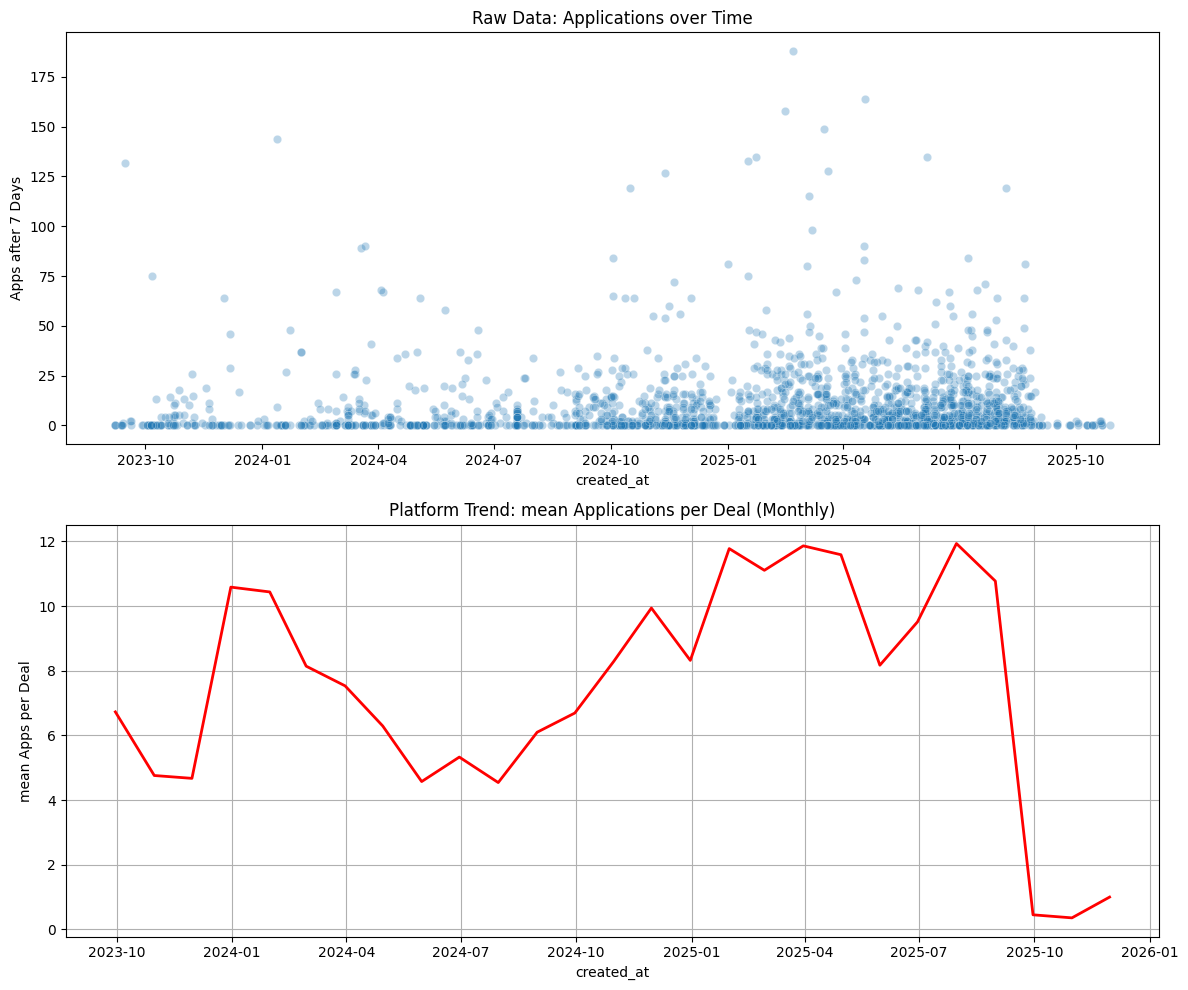

Correlation between Time and Application Count: 0.0816
Correlation between Monthly Deal Volume and mean of apps_after_7_days: 0.6773


In [24]:
visualise_var_over_time('apps_after_7_days', 'mean')

- Sum of 'applications after 7 days' per deal over time

/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_39953/3926852071.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = og_df.set_index('created_at').resample('M')[


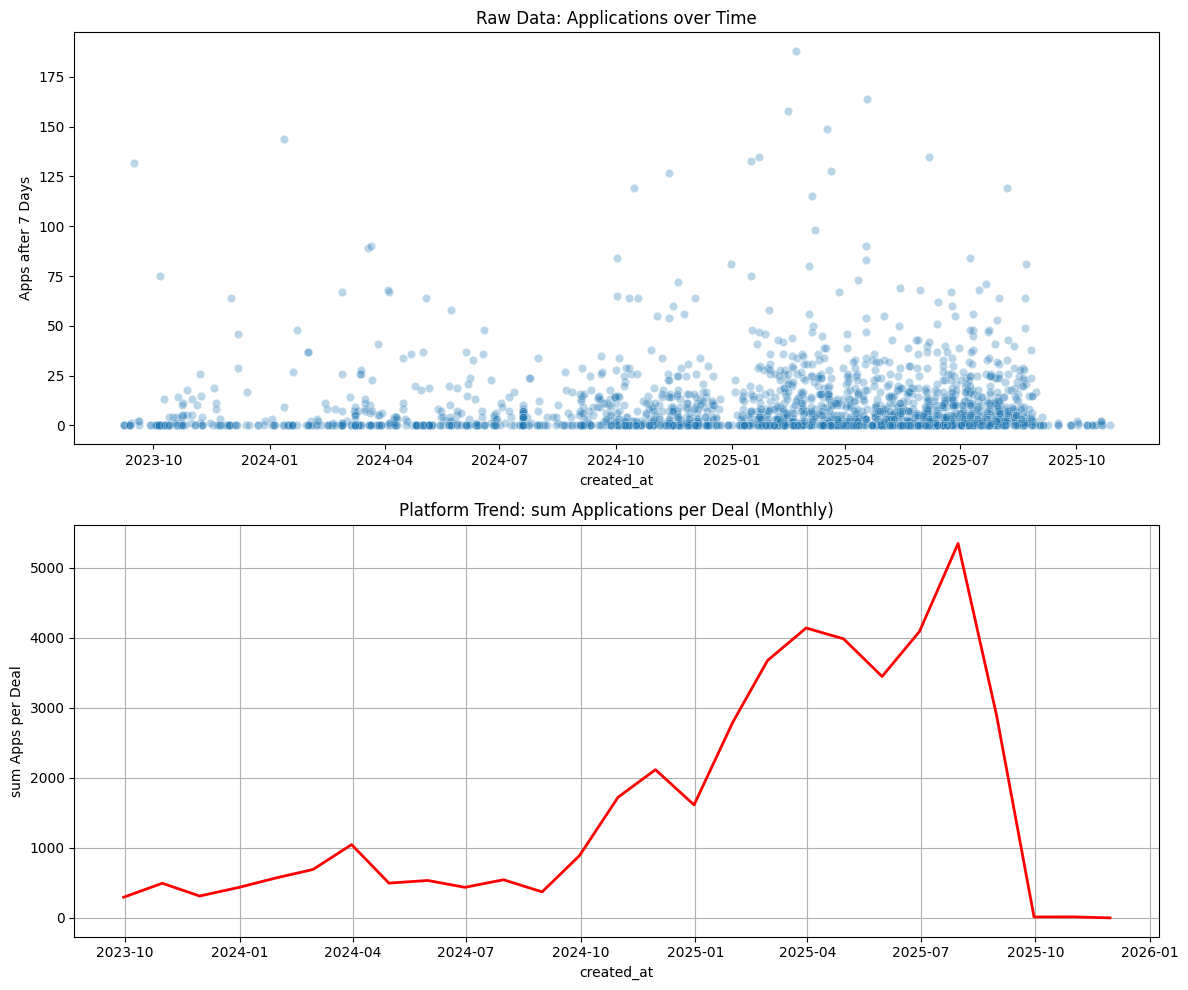

Correlation between Time and Application Count: 0.0816
Correlation between Monthly Deal Volume and sum of apps_after_7_days: 0.9733


In [25]:
visualise_var_over_time('apps_after_7_days', 'sum')

In [27]:
subset_final_df = final_df[final_df.prompt_id == 'd6ac463714']

# 1. Ensure datetime format
subset_final_df['created_at'] = pd.to_datetime(subset_final_df['created_at'])

# 2. Extract a numeric 'Time' feature for correlation (e.g., Days since start)
# We subtract the minimum date to get a "Day 0", "Day 1"... counter
start_date = subset_final_df['created_at'].min()
subset_final_df['days_since_start'] = (
    subset_final_df['created_at'] - start_date).dt.days

/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_39953/2899835839.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_final_df['created_at'] = pd.to_datetime(subset_final_df['created_at'])
/var/folders/j6/_nwsrmhx5w1fj_nrxmrss8180000gq/T/ipykernel_39953/2899835839.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_final_df['days_since_start'] = (


Correlation between Time and Quality: 0.1116


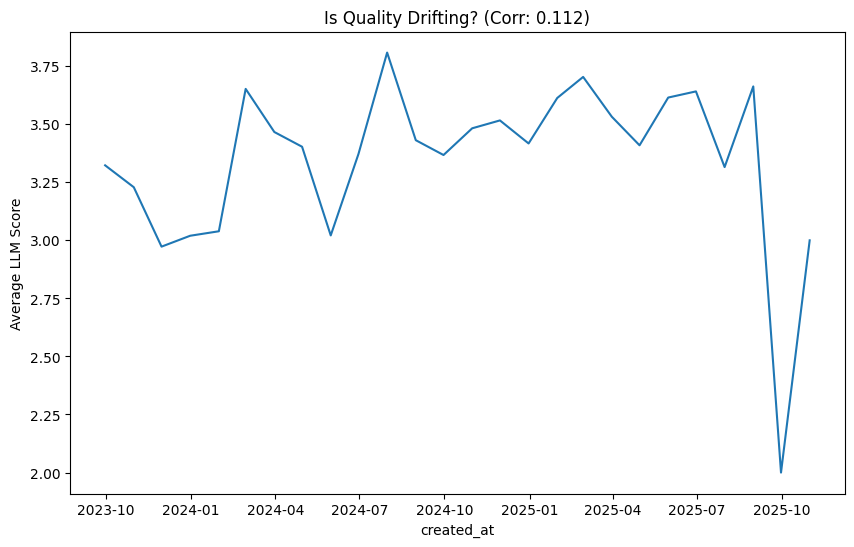

In [28]:
# 1. Check if Quality correlates with Time
# We use the 'days_since_start' we created earlier
import matplotlib.pyplot as plt
import seaborn as sns
quality_time_corr = subset_final_df[[
    'days_since_start', 'mean_rating']].corr().iloc[0, 1]

print(f"Correlation between Time and Quality: {quality_time_corr:.4f}")

# 2. Visualize the drift

plt.figure(figsize=(10, 6))
# Plot monthly average quality to reduce noise
monthly_quality = subset_final_df.set_index('created_at').resample('ME')[
    'mean_rating'].mean()

sns.lineplot(x=monthly_quality.index, y=monthly_quality.values)
plt.title(f"Is Quality Drifting? (Corr: {quality_time_corr:.3f})")
plt.ylabel("Average LLM Score")
plt.show()

## General

- Deals with zero applications

In [28]:
og_df_zero_apps = og_df[og_df.applicants_applications_count == 0]
og_df_zero_apps

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD,days_since_start
1,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",019689e5-f489-00c8-8c26-06b3ea0961a5,uploads/deals/019689e5-f54b-ffff-dbed-637e9d2a...,5000,None,2023-11-28 14:59:51.626780,2023-11-28 14:59:51.626780,2025-05-01 03:31:11.600095,NaT,...,None,None,None,None,0,2025-05-01,0,0,0.0,82
7,0,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e4-306b-00c8-d98c-70210470c288,uploads/deals/019689e4-3146-ffff-e4a6-efb122b1...,2500,None,2024-12-21 13:36:47.610355,2024-12-21 13:36:47.610355,2025-05-01 03:29:15.743063,NaT,...,None,None,None,None,0,2025-05-01,0,0,0.0,471
20,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf30-3d9e-00c8-45de-a6091919cc67,,1500,None,NaT,2025-05-14 14:26:07.390204,2025-05-14 14:38:34.607315,2025-05-15 09:33:30.588079+00:00,...,None,None,None,None,0,2025-05-14,0,0,NaN,615
22,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-4ed5-00c8-4120-a08641f9f6f7,uploads/deals/019689e2-4ff4-ffff-5f8b-033c32b8...,5000,None,2024-05-02 09:27:34.909380,2024-05-02 09:27:34.909380,2025-05-01 03:27:12.709921,NaT,...,None,None,None,None,0,2025-05-01,0,0,4.0,237
23,0,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'}]",0196cf35-c5d6-00c8-4d97-bbfef60b2cf5,,2500,None,NaT,2025-05-14 14:32:09.942486,2025-05-14 14:32:15.868080,2025-05-14 14:35:11.325650+00:00,...,None,None,None,None,0,2025-05-14,0,0,NaN,615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5041,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-8d77-00c8-af2c-88afecf6d330,uploads/deals/019689e4-8e9b-ffff-f2dc-de9dc691...,2500,None,2025-02-05 10:50:49.679167,2025-02-05 10:50:49.679167,2025-10-28 10:51:10.763570,NaT,...,None,None,None,0199f1b1-a870-015e-9154-4fe289974050,0,2025-10-28,0,0,0.0,517
5068,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-9589-00c8-7dcb-d0bd27e9de7d,uploads/deals/019689e4-96ac-ffff-a035-6766138f...,50000,None,2025-04-27 09:08:03.830735,2025-04-27 09:08:03.830735,2025-10-28 10:50:03.356636,NaT,...,None,None,None,0199f1a2-caa1-015e-b4db-2edf3b482672,0,2025-10-28,0,0,3.0,597
5098,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e4-a9d4-00c8-6d70-59ec50167ab7,uploads/deals/019689e4-aa38-ffff-e781-3a523780...,5000,None,2024-03-15 13:45:49.561715,2024-03-15 13:45:49.561715,2025-10-28 10:54:48.369215,NaT,...,None,None,None,0199f1cd-8862-015e-ca76-0be502d21b6a,0,2025-10-28,0,0,0.0,190
5108,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",0198324e-635d-00c8-7d1d-bbb0b902b0d9,,10000,None,NaT,2025-07-22 13:24:14.813323,2025-10-28 11:04:12.121141,NaT,...,None,None,None,0199f18e-af17-015e-23aa-c780e5c4a2b8,0,2025-10-28,0,0,NaN,684


- Deals with positive number of applications but no applications after 7 days

In [29]:
og_df[(og_df['apps_after_7_days'] == 0) & (
    og_df['applicants_applications_count'] > 0)]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD,days_since_start
24,65,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",019689e5-c8c2-00c8-79f3-9992362edeea,uploads/deals/019689e5-c976-ffff-edd8-529b3e62...,5000,None,NaT,2023-11-22 12:13:25.712323,2025-05-01 03:31:00.674606,2024-02-10 14:35:49.163784+00:00,...,None,None,None,None,65,2025-05-01,0,0,NaN,76
25,56,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e4-bde0-00c8-dcce-bb7de653145b,uploads/deals/019689e4-be81-ffff-4174-cd8a5c2d...,10000,None,2025-01-13 15:37:11.226833,2025-01-13 15:37:11.226833,2025-05-22 04:00:16.868866,NaT,...,None,None,None,None,56,2025-05-22,0,0,0.0,494
31,18,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196f22e-9224-00c8-1f18-378560b58a42,uploads/deals/0196f22a-eae6-ffff-e2f6-8a112033...,1500,None,2025-05-21 09:31:00.752564,2025-05-21 09:31:00.516748,2025-10-28 10:52:44.677317,NaT,...,None,None,None,0199f1d9-ba9c-015e-98dd-31cc262c0e04,18,2025-10-28,0,0,0.0,621
33,6,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e3-770b-00c8-d2ee-83252084a97a,uploads/deals/019689e3-77aa-ffff-9af7-e4cde670...,2500,None,NaT,2024-02-16 13:13:22.821687,2025-05-01 03:28:28.371244,2024-02-24 14:08:58.711124+00:00,...,None,None,None,None,6,2025-05-01,0,0,NaN,162
44,148,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-287d-00c8-258d-b4e8df65b7a5,uploads/deals/019689e3-294c-ffff-313b-5c2680e5...,5000,None,2023-09-28 12:34:50.532202,2023-09-28 12:34:50.532202,2025-10-28 10:56:13.372705,NaT,...,None,None,None,0199f1d2-2345-015e-d386-0d22efe5edcf,148,2025-10-28,0,0,0.0,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4971,3,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",0196d4a5-62a4-00c8-afe1-0e592c281122,uploads/deals/0196d4a4-a3e1-ffff-f2c5-d2aebc1c...,10000,None,2025-05-15 15:52:10.852458,2025-05-15 15:52:10.660506,2025-06-15 21:59:22.317427,NaT,...,None,None,None,None,3,2025-06-15,0,0,6.0,616
4993,1,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",0196ceae-4334-00c8-65d6-7fb556b9ba6f,uploads/deals/0196ceae-1f69-ffff-955d-61eb09b2...,5000,None,2025-05-14 12:04:09.257984,2025-05-14 12:04:09.140652,2025-05-14 12:04:09.258113,NaT,...,None,None,None,None,1,2025-05-14,0,0,37.0,615
5006,6,"[{'id': 25, 'name': 'Cooking', 'slug': 'Cookin...",019689e4-8482-00c8-60fa-3cb52ac85ff5,uploads/deals/019689e4-8597-ffff-9779-60501bb9...,2500,None,2025-05-20 11:35:10.937802,2025-04-25 14:03:19.480448,2025-10-28 10:49:41.201605,NaT,...,None,None,None,0199f19e-56a2-015e-a4aa-5d54b2c701bb,6,2025-10-28,0,0,13.0,596
5019,31,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-2d2a-00c8-8b96-27c693c7ab51,uploads/deals/019689e3-2d91-ffff-6b6c-b8dfc7c8...,5000,None,2024-02-06 10:29:13.139738,2024-02-06 10:29:13.139738,2025-05-01 03:28:09.341890,NaT,...,None,None,None,None,31,2025-05-01,0,0,28.0,152


- Within-company variance

In [29]:
text_stats = og_df.groupby('partner_id')['apps_after_7_days'].agg([
    'count', 'mean', 'var', 'std'])
text_stats

,count,mean,var,std
partner_id,,,,
1,6,0.000000,0.000000,0.000000
2,1,0.000000,NaN,NaN
3,6,0.166667,0.166667,0.408248
4,13,18.307692,1863.730769,43.170948
5,2,0.000000,0.000000,0.000000
...,...,...,...,...
3460,1,0.000000,NaN,NaN
3468,1,0.000000,NaN,NaN
3471,1,0.000000,NaN,NaN


In [30]:
# 1. Group by identical deal text
# We calculate count (to find dupes), mean, and variance for each unique text
text_stats = og_df.groupby('deal_text')['apps_after_7_days'].agg([
    'count', 'mean', 'var', 'std'])

# 2. Filter: We only care about texts that were posted more than once
# We also drop NaNs in variance (which happen if count < 2)
duplicates = text_stats[text_stats['count'] > 1].dropna()

print(f"Found {len(duplicates)} unique texts that were posted multiple times.")
print(
    f"Total observations involved in duplicates: {duplicates['count'].sum()}")

# 3. Calculate the "Pure Error" vs "Total Variance"
# Pure Error = The average variance *within* these identical groups
pure_error_variance = duplicates['var'].mean()

# Total Variance = The variance of the entire dataset (ignoring text identity)
total_variance = og_df['apps_after_7_days'].var()

# 4. The "Unexplainable" Ratio
noise_ratio = pure_error_variance / total_variance

print(f"\n--- Variance Analysis ---")
print(f"Total Dataset Variance:   {total_variance:.2f}")
print(f"Variance within Reposts:  {pure_error_variance:.2f} (Pure Error)")
print(f"Noise Ratio:              {noise_ratio:.2%}")

# 5. Interpretation
if noise_ratio > 0.5:
    print("\n⚠️ CRITICAL: Over 50% of the variation in applications has nothing to do with the text.")
    print("Even if you trained a perfect AI, it could only explain <50% of the results.")
else:
    print(
        f"\n✅ Good News: Only {noise_ratio:.1%} of variance is random noise.")
    print("There is still plenty of signal for the model to learn.")

Found 293 unique texts that were posted multiple times.
Total observations involved in duplicates: 788

--- Variance Analysis ---
Total Dataset Variance:   268.49
Variance within Reposts:  131.02 (Pure Error)
Noise Ratio:              48.80%

✅ Good News: Only 48.8% of variance is random noise.
There is still plenty of signal for the model to learn.


- Partners with many deals

In [32]:
partner_count = og_df.partner_id.value_counts()
partner_count

# og_df = pd.merge(og_df, partner_count, on = 'partner_id')
# partner_count

partner_id
85      73
461     73
6       38
871     30
401     27
        ..
1994     1
2002     1
1692     1
2193     1
1051     1
Name: count, Length: 1635, dtype: int64

In [33]:
# Proportion of observations that come from partners that have more than 10 total deals

partner_count[partner_count > 10].sum() / partner_count.sum()

np.float64(0.21829924650161464)

- Social requirement type

In [13]:
og_df.social_requirement_type_id.value_counts()

social_requirement_type_id
3.0     1860
2.0     1337
4.0      610
1.0      519
5.0      165
6.0       86
34.0      54
Name: count, dtype: int64

In [17]:
og_df.groupby('social_requirement_type_id')['applicants_applications_count'].agg('mean')

social_requirement_type_id
1.0     23.736031
2.0     39.523560
3.0     30.517204
4.0     22.562295
5.0      8.345455
6.0     30.755814
34.0     2.518519
Name: applicants_applications_count, dtype: float64

In [18]:
og_df[og_df.partner_id == 4]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
505,1,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-5f87-00c8-99d5-2d1db6204f32,uploads/deals/019689e3-603a-ffff-d2cd-148f7533...,2500,None,2023-10-02 14:07:43.198076,2023-10-02 14:07:43.198076,2025-05-01 03:28:22.309643,NaT,...,204.0,None,None,None,None,1,2025-05-01,0,0,0.0
944,326,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e3-b5d1-00c8-b43f-212bb3732b1c,uploads/deals/019689e3-b636-ffff-5668-6e78d27e...,50000,None,2023-10-06 11:32:11.616933,2023-10-06 11:32:11.616933,2025-05-01 03:28:44.208848,NaT,...,242.0,None,None,None,None,326,2025-05-01,0,19,0.0
1520,0,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e4-55b8-00c8-e758-36a3fe17d11d,uploads/deals/019689e4-56ae-ffff-0d87-9a008138...,5000,None,NaT,2024-03-11 09:38:29.167985,2025-05-01 03:29:26.120218,2024-03-11 09:45:51.483595+00:00,...,772.0,None,None,None,None,0,2025-05-01,0,0,16.0
1779,144,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-9b0d-00c8-db74-83e494e323cb,uploads/deals/019689e2-9b65-ffff-c7ff-8c5e28b5...,2500,None,2024-01-12 11:01:17.534158,2024-01-12 11:01:17.534158,2025-10-28 10:56:06.614862,NaT,...,574.0,None,None,None,0199f1d3-e270-015e-e659-f097472753a4,144,2025-10-28,0,144,0.0
1921,0,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e4-efda-00c8-0ecc-02a2a25cdfba,uploads/deals/019689e4-f18b-ffff-54ed-01dc63cf...,2500,None,NaT,2024-07-08 16:44:41.926613,2025-05-01 03:30:06.205992,2024-07-08 16:45:39.090249+00:00,...,1272.0,None,None,None,None,0,2025-05-01,0,0,1.0
2838,118,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-5128-00c8-994a-73657a1b0ca4,uploads/deals/019689e3-51c7-ffff-0a34-807e23ca...,50000,None,2023-10-02 12:52:21.704136,2023-10-02 12:52:21.704136,2025-10-28 10:56:09.195922,NaT,...,199.0,None,None,None,0199f1d3-e270-015e-e659-f097472753a4,118,2025-10-28,0,0,6.0
2874,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e3-53e9-00c8-3359-bf323786e75e,uploads/deals/019689e3-5471-ffff-7012-268bdc8f...,2500,None,2023-10-02 13:12:01.216469,2023-10-02 13:12:01.216469,2025-10-28 10:56:09.405883,NaT,...,200.0,None,None,None,0199f1d3-e270-015e-e659-f097472753a4,0,2025-10-28,0,0,NaN
2898,0,"[{'id': 33, 'name': 'Entertainment', 'slug': '...",019689e5-dbeb-00c8-229e-10de82cf0064,uploads/deals/019689e5-e07d-ffff-d34e-4e25c628...,2500,None,NaT,2024-10-24 09:38:49.844412,2025-05-01 03:31:06.277996,2024-10-24 09:46:10.041301+00:00,...,1965.0,None,None,None,None,0,2025-05-01,0,0,NaN
2906,0,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e2-3189-00c8-68db-cc5381833f3d,uploads/deals/019689e2-3335-ffff-f63e-175640fe...,5000,None,NaT,2024-05-01 13:20:43.146930,2025-05-01 03:27:05.899254,2024-05-02 09:31:05.213134+00:00,...,1056.0,None,None,None,None,0,2025-05-01,0,0,5.0
2923,0,"[{'id': 40, 'name': 'Drinks', 'slug': 'Champag...",019689e2-c297-00c8-c378-191d3b5dff3b,uploads/deals/019689e2-c331-ffff-c0eb-209f0e7c...,2500,None,NaT,2024-01-19 14:41:56.632128,2025-05-01 03:27:42.095928,2024-01-19 14:42:00.450313+00:00,...,589.0,None,None,None,None,0,2025-05-01,0,0,NaN


In [19]:
og_df[og_df['social_requirement_type_id'] == 6]

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,created_at,updated_at,deleted_at,...,legacy_id,tags,gender,featured_image,company_id,test_nr_of_apps,update_at_date,diff,apps_after_7_days,apps_after_7_days_OLD
26,6,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}, ...",0198608d-899b-00c8-d331-75d1dabc8a2c,uploads/deals/0198608c-b810-ffff-ba12-ffa0228c...,50000,None,2025-07-31 12:55:45.445527,2025-07-31 12:55:45.307628,2025-10-28 10:50:05.414297,NaT,...,NaN,None,None,None,0199f1a3-3d16-015e-52ca-006b924bdcfc,6,2025-10-28,0,5,5.0
121,25,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e5-95a1-00c8-9b7c-153878e259f6,uploads/deals/019689e5-9657-ffff-4b9f-747eb6b9...,50000,None,2023-11-15 11:54:31.853721,2023-11-15 11:54:31.853721,2025-10-28 10:55:42.620217,NaT,...,450.0,None,None,None,0199f1d4-9856-015e-5435-d593bd80df8f,25,2025-10-28,0,15,23.0
174,7,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",0196d494-dc4a-00c8-e58e-1a638ebcfdae,uploads/deals/0196d491-3f06-ffff-57c0-8d3054b9...,50000,None,2025-05-15 15:34:07.850723,2025-05-15 15:34:07.690325,2025-08-18 04:00:11.142413,NaT,...,NaN,None,None,None,None,7,2025-08-18,0,3,3.0
229,0,"[{'id': 33, 'name': 'Entertainment', 'slug': '...",019689e2-639f-00c8-8cc0-63a1af7916c4,uploads/deals/019689e2-64ce-ffff-b723-98ee5492...,50000,None,2023-12-20 15:52:33.629474,2023-12-20 15:52:33.629474,2025-05-01 03:27:17.974751,NaT,...,545.0,None,None,None,None,0,2025-05-01,0,0,0.0
283,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e2-7945-00c8-a300-5446558001e1,uploads/deals/019689e2-79e6-ffff-d2ee-2998d00d...,50000,None,2025-02-27 15:55:25.226241,2025-02-27 15:55:25.226241,2025-05-01 03:27:23.210618,NaT,...,3553.0,None,None,None,None,0,2025-05-01,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4548,39,"[{'id': 31, 'name': 'Lifestyle', 'slug': 'Mart...",019689e3-0ce5-00c8-3006-b0f798dbdde0,uploads/deals/019689e3-0e2b-ffff-5f65-d0249c67...,50000,None,2025-04-08 14:48:07.695676,2025-04-08 14:48:07.695676,2025-05-01 03:28:01.376729,NaT,...,4105.0,None,None,None,None,39,2025-05-01,0,25,0.0
4761,73,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",01976412-1851-00c8-07df-59a256bdda52,uploads/deals/01976411-3125-ffff-dd39-a7644dfe...,50000,None,2025-06-12 12:16:37.062524,2025-06-12 12:16:36.945143,2025-09-14 04:00:04.933481,NaT,...,NaN,None,None,None,None,73,2025-09-14,0,51,8.0
4829,1,"[{'id': 37, 'name': 'Luxury', 'slug': 'Sketch-...",0198a841-9305-00c8-cf36-32f2d774ed17,uploads/deals/0198a83f-c79f-ffff-91b9-22f4cb81...,50000,None,2025-08-14 11:05:26.728556,2025-08-14 11:05:26.533184,2025-09-14 04:00:05.630671,NaT,...,NaN,None,None,None,None,1,2025-09-14,0,1,2.0
5068,0,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019689e4-9589-00c8-7dcb-d0bd27e9de7d,uploads/deals/019689e4-96ac-ffff-a035-6766138f...,50000,None,2025-04-27 09:08:03.830735,2025-04-27 09:08:03.830735,2025-10-28 10:50:03.356636,NaT,...,4362.0,None,None,None,0199f1a2-caa1-015e-b4db-2edf3b482672,0,2025-10-28,0,0,3.0
